11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


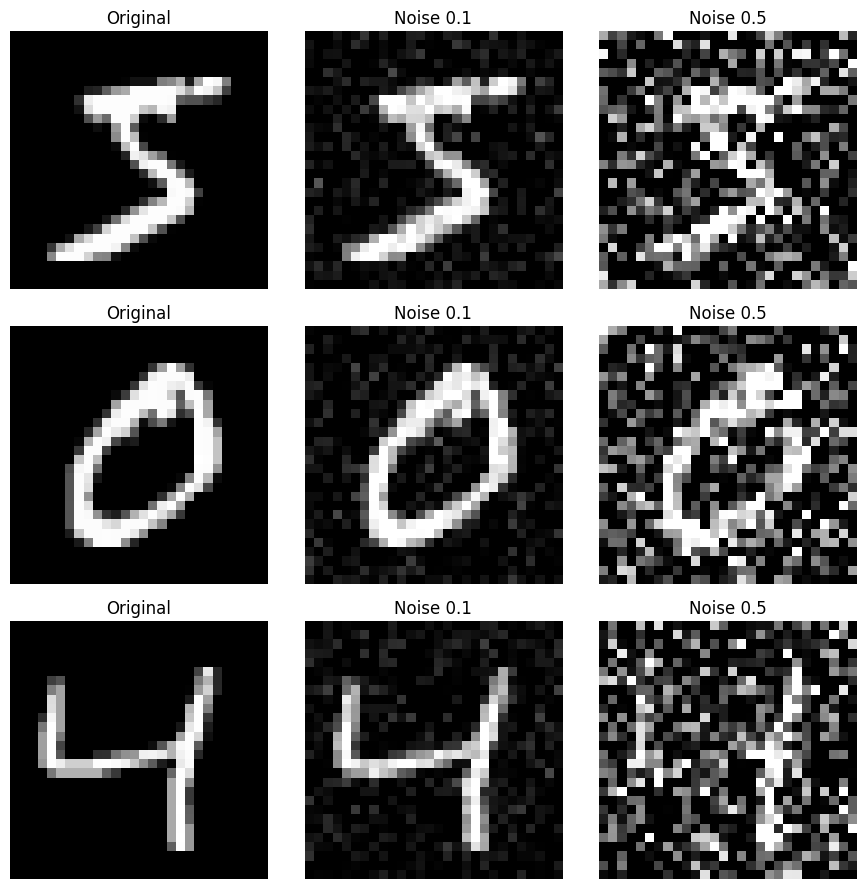

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist

# Load and preprocess MNIST
(x_train, _), (x_test, _) = mnist.load_data()

x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

x_train = np.reshape(x_train, (len(x_train), 28, 28, 1))
x_test = np.reshape(x_test, (len(x_test), 28, 28, 1))

# Generate noisy versions
noise_factor_low = 0.1
noise_factor_high = 0.5

x_train_noisy_low = x_train + noise_factor_low * np.random.normal(
    loc=0.0, scale=1.0, size=x_train.shape
)

x_train_noisy_high = x_train + noise_factor_high * np.random.normal(
    loc=0.0, scale=1.0, size=x_train.shape
)

x_test_noisy_low = x_test + noise_factor_low * np.random.normal(
    loc=0.0, scale=1.0, size=x_test.shape
)

x_test_noisy_high = x_test + noise_factor_high * np.random.normal(
    loc=0.0, scale=1.0, size=x_test.shape
)

# Clip pixel values to [0, 1]
x_train_noisy_low = np.clip(x_train_noisy_low, 0., 1.)
x_test_noisy_low = np.clip(x_test_noisy_low, 0., 1.)

x_train_noisy_high = np.clip(x_train_noisy_high, 0., 1.)
x_test_noisy_high = np.clip(x_test_noisy_high, 0., 1.)

# Visualize in a 3 x 3 grid
n = 3  # number of images to show
plt.figure(figsize=(9, 9))

for i in range(n):
    # Original image
    ax = plt.subplot(n, 3, i * 3 + 1)
    plt.imshow(x_train[i].reshape(28, 28), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Low noise image
    ax = plt.subplot(n, 3, i * 3 + 2)
    plt.imshow(x_train_noisy_low[i].reshape(28, 28), cmap='gray')
    plt.title("Noise 0.1")
    plt.axis('off')

    # High noise image
    ax = plt.subplot(n, 3, i * 3 + 3)
    plt.imshow(x_train_noisy_high[i].reshape(28, 28), cmap='gray')
    plt.title("Noise 0.5")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
def build_encoder(input_shape=(28, 28, 1)):
    """
    Builds the encoder part of the convolutional autoencoder.
    Parameters:
    input_shape (tuple): Shape of the input image. Default is (28, 28, 1) for MNIST.
    Returns:
    input_img (Keras Input): Input layer of the model.
    encoded (Keras Tensor): Encoded representation after convolution and pooling.
    """
    input_img = Input(shape=input_shape, name="input")
    x = Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
    x = MaxPooling2D((2, 2), padding='same')(x)
    x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    encoded = MaxPooling2D((2, 2), padding='same', name="encoded")(x)
    return input_img, encoded

In [ ]:
def build_decoder(encoded_input):
    """
    Builds the decoder part of the convolutional autoencoder.
    Parameters:
    encoded_input (Keras Tensor): The output from the encoder.

    9

    6CS012 Tutorial - 7 Siman Giri

    Returns:
    decoded (Keras Tensor): The reconstructed output after upsampling and
    convolution.
    """
    x = Conv2D(64, (3, 3), activation='relu', padding='same')(encoded_input)
    x = UpSampling2D((2, 2))(x)
    x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    x = UpSampling2D((2, 2))(x)
    decoded = Conv2D(1, (3, 3), activation='sigmoid', padding='same', name="decoded")(x)
    return decoded

In [ ]:
def build_autoencoder():
    """
    Constructs and compiles the full convolutional autoencoder by connecting encoder and
    decoder.
    Returns:
    autoencoder (Keras Model): Compiled autoencoder model.
    """
    input_img, encoded_output = build_encoder()
    decoded_output = build_decoder(encoded_output)
    autoencoder = Model(inputs=input_img, outputs=decoded_output, name="autoencoder")
    autoencoder.compile(optimizer=Adam(), loss='binary_crossentropy')
    return autoencoder

In [ ]:
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

autoencoder = build_autoencoder()
autoencoder.summary()

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoded (MaxPooling2D)          │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoded (Conv2D)                │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Build the autoencoder from previous steps
autoencoder = build_autoencoder()
# Train with noisy input and clean target
history = autoencoder.fit(
x_train_noisy_high, x_train,
epochs=10,
batch_size=128,
shuffle=True,
validation_data=(x_test_noisy_high, x_test)
)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - loss: 0.1521 - val_loss: 0.1129
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.1098 - val_loss: 0.1053
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.1044 - val_loss: 0.1020
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.1017 - val_loss: 0.1005
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.1001 - val_loss: 0.0986
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0989 - val_loss: 0.0975
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0979 - val_loss: 0.0972
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0972 - val_loss: 0.0962
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0966 - val_loss: 0.0956
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.0960 - val_loss: 0.0954


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


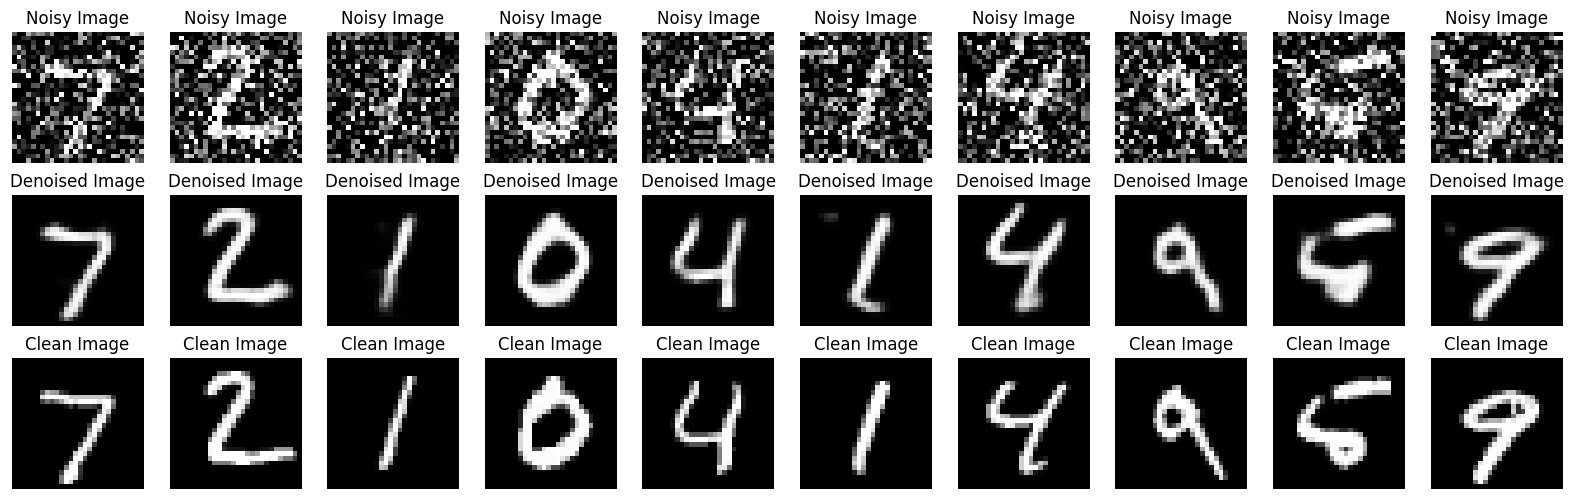

In [ ]:
# Predict the denoised images from noisy test images
denoised_images = autoencoder.predict(x_test_noisy_high)

# Function to display images
def plot_images(noisy_images, denoised_images, clean_images, n=10):
    plt.figure(figsize=(20, 6))
    for i in range(n):
        # Plot noisy images
        plt.subplot(3, n, i + 1)
        plt.imshow(noisy_images[i].reshape(28, 28), cmap='gray')
        plt.title("Noisy Image")
        plt.axis('off')

        # Plot denoised images
        plt.subplot(3, n, i + 1 + n)
        plt.imshow(denoised_images[i].reshape(28, 28), cmap='gray')
        plt.title("Denoised Image")
        plt.axis('off')

        # Plot clean images
        plt.subplot(3, n, i + 1 + 2 * n)
        plt.imshow(clean_images[i].reshape(28, 28), cmap='gray')
        plt.title("Clean Image")
        plt.axis('off')
    plt.show()

# Display the first 10 images
plot_images(x_test_noisy_high, denoised_images, x_test, n=10)

# **Exercise**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [16]:
import os
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D
from tensorflow.keras.layers import UpSampling2D
from tensorflow.keras.optimizers import Adam

In [25]:
import os
import numpy as np
from PIL import Image

dataset_path = "/content/drive/MyDrive/ai/DevanagariHandwrittenDigitDataset"

images = []
labels = []

img_size = 32

# Check dataset path exists
print("Dataset Path Exists:", os.path.exists(dataset_path))

for dataset_type_folder in os.listdir(dataset_path): # e.g., 'Test', 'Train'

    dataset_type_path = os.path.join(dataset_path, dataset_type_folder)

    if os.path.isdir(dataset_type_path):

        print("Reading Folder:", dataset_type_folder)

        for digit_folder_name in os.listdir(dataset_type_path): # e.g., 'digit_0', 'digit_1'

            digit_folder_path = os.path.join(dataset_type_path, digit_folder_name)

            if os.path.isdir(digit_folder_path):

                for img_name in os.listdir(digit_folder_path): # actual image files

                    img_path = os.path.join(digit_folder_path, img_name)

                    try:
                        img = Image.open(img_path).convert("L")
                        img = img.resize((img_size, img_size))

                        img_array = np.array(img)

                        images.append(img_array)
                        labels.append(digit_folder_name) # Capture the digit label

                    except Exception as e:
                        print("Error loading:", img_path)
                        print(e)

images = np.array(images)

print("Total Images Loaded:", len(images))

Dataset Path Exists: True
Reading Folder: Test
Reading Folder: Train
Total Images Loaded: 20000


In [17]:
##Normalizing the images
images = images.astype('float32') / 255.0

In [18]:
#Reshaping the images for CNN
images = images.reshape(-1, img_size, img_size, 1)

print(images.shape)

(0, 32, 32, 1)


In [26]:
#Splitting the data
x_train, x_val = train_test_split(
    images,
    test_size=0.2,
    random_state=42
)


In [27]:
#adding noise to the image
noise_factor = 0.4

x_train_noisy = x_train + noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=x_train.shape
)

x_val_noisy = x_val + noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=x_val.shape
)

# Clip values between 0 and 1
x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_val_noisy = np.clip(x_val_noisy, 0., 1.)

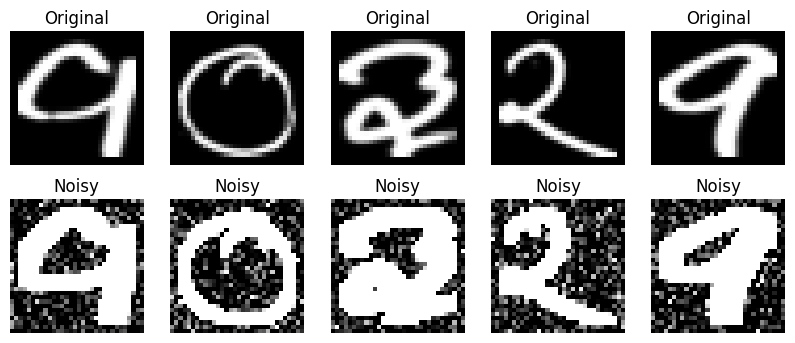

In [28]:
#visualize noisy images
plt.figure(figsize=(10,4))

for i in range(5):

    ax = plt.subplot(2,5,i+1)
    plt.imshow(x_train[i].reshape(32,32), cmap='gray')
    plt.title("Original")
    plt.axis("off")

    ax = plt.subplot(2,5,i+6)
    plt.imshow(x_train_noisy[i].reshape(32,32), cmap='gray')
    plt.title("Noisy")
    plt.axis("off")

plt.show()

In [29]:
#Building the denoising convulational autoencoder
input_img = Input(shape=(32,32,1))

#Encoder
x = Conv2D(32, (3,3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2,2), padding='same')(x)

x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
x = MaxPooling2D((2,2), padding='same')(x)

x = Conv2D(128, (3,3), activation='relu', padding='same')(x)
encoded = MaxPooling2D((2,2), padding='same')(x)

#  Decoder
x = Conv2D(128, (3,3), activation='relu', padding='same')(encoded)
x = UpSampling2D((2,2))(x)

x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
x = UpSampling2D((2,2))(x)

x = Conv2D(32, (3,3), activation='relu', padding='same')(x)
x = UpSampling2D((2,2))(x)

decoded = Conv2D(1, (3,3),
                 activation='sigmoid',
                 padding='same')(x)

autoencoder = Model(input_img, decoded)

autoencoder.compile(
    optimizer=Adam(),
    loss='binary_crossentropy'
)

autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 4, 4, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 64)       │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 332,801 (1.27 MB)

 Trainable params: 332,801 (1.27 MB)

 Non-trainable params: 0 (0.00 B)

In [30]:
#Training the model
history = autoencoder.fit(
    x_train_noisy,
    x_train,
    epochs=20,
    batch_size=128,
    shuffle=True,
    validation_data=(x_val_noisy, x_val)
)

Epoch 1/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 11s 25ms/step - loss: -933.4163 - val_loss: -969.1841
Epoch 2/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: -969.1627 - val_loss: -969.1841
Epoch 3/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: -969.1628 - val_loss: -969.1841
Epoch 4/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: -969.1627 - val_loss: -969.1841
Epoch 5/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: -969.1628 - val_loss: -969.1841
Epoch 6/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: -969.1630 - val_loss: -969.1841
Epoch 7/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: -969.1630 - val_loss: -969.1841
Epoch 8/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: -969.1629 - val_loss: -969.1841
Epoch 9/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: -969.1627 - val_loss: -969.1841
Epoch 10/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: -969.1625 - val_loss: -969.1841
Epoch 11/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: -969.1

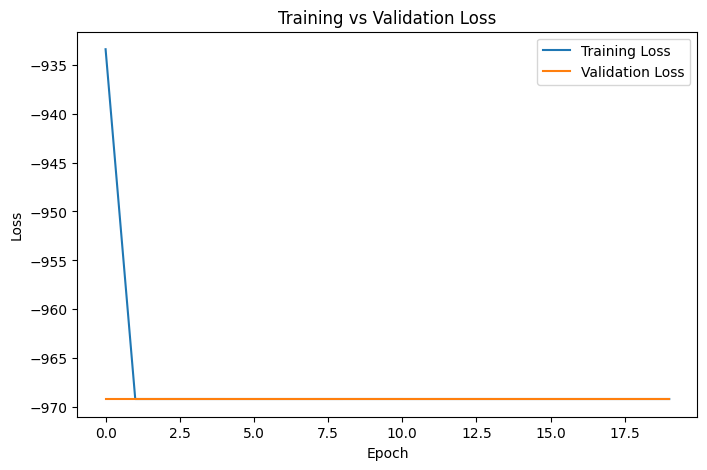

In [31]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()

In [32]:
#Predicting denoised images
decoded_imgs = autoencoder.predict(x_val_noisy)

125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


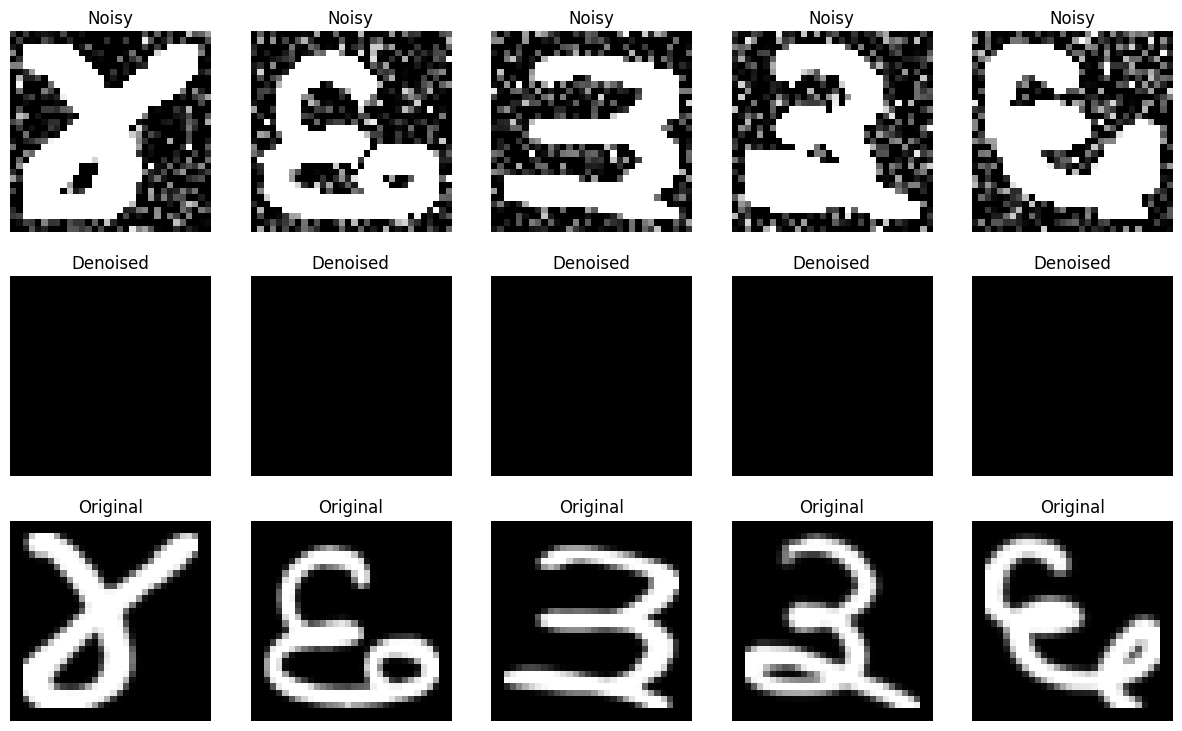

In [33]:
#visualizing results
n = 5

plt.figure(figsize=(15,9))

for i in range(n):

    # Noisy Image
    ax = plt.subplot(3,n,i+1)
    plt.imshow(x_val_noisy[i].reshape(32,32), cmap='gray')
    plt.title("Noisy")
    plt.axis("off")

    # Denoised Image
    ax = plt.subplot(3,n,i+n+1)
    plt.imshow(decoded_imgs[i].reshape(32,32), cmap='gray')
    plt.title("Denoised")
    plt.axis("off")

    # Original Image
    ax = plt.subplot(3,n,i+2*n+1)
    plt.imshow(x_val[i].reshape(32,32), cmap='gray')
    plt.title("Original")
    plt.axis("off")

plt.show()

# Effect of Noise Factor
0.2: Easier reconstruction

0.4: Good balance

0.6: Images become blurry

---
# Effect of More Layers
2 Layers: Lower quality reconstruction

4 Layers: Better denoising

6 Layers: Better features but slower training



---
# Effect of Epochs
10: Underfitting

20: Good results

50: Better quality but longer training


In this exercise, a Denoising Convolutional Autoencoder was developed
for the Devnagari Handwritten Digit Dataset.

Gaussian noise was added to the images, and the autoencoder successfully
learned to reconstruct clean images from noisy inputs.

The convolutional architecture extracted important spatial features,
while the decoder reconstructed the denoised outputs effectively.

Increasing the number of layers and training epochs improved the
reconstruction quality, although training time also increased.